# Metropolis Hastings Algorithm

In the final section of `MCMC_theory.ipynb` we coded up the Metropolis algorithm for sampling a bi-modal distribution. The Metropolis algorithm requires that
the proposal distribution is symmetric. This symmetry allowed the acceptance ratio to be expressed as:
$$
r_M = \frac{p(\theta^* | y)}{p(\theta_{t-1}|y)}
$$
where $\theta^*$ is the proposed parameter value, and $y$ is the data. The **Metropolis Hastings** algorithm generalizes the basic Metropolis algorithm in two ways:
1. The proposal distribution need not be symmetric;
2. The acceptance ratio $r$ is modified to account for asymmetry as:
$$
    r_{MH} = \frac{p(\theta^*|y) / J_t(\theta^*|\theta_{t-1})}{p(\theta_{t-1}|y) / J_t(\theta_{t-1}|\theta^*)}\;,
$$
where $J_t$ is the the proposal distribution at time $t$. We see that this generalizes the Metropolis algorithm since if we restrict $J_t$ to a symmetric
distribution, the $J_t$ values in the numerator and denominator of $r_{MH}$ equate and cancel out, yielding $r_M$. 

## Metropolis Hasting Through Example: Bi Modal Distribution

We will get a feel for the Metropolis Hastings algorithm by recreating the bi modal distribution example seen in `MCMC_theory.ipynb`. Our objective in this section is as follows:

Implement a Metropolis Hastings sampler for a bi modal continuous distribution using a non-symmetric proposal distribution. The target distribution will be the mixture of Gaussians:
$$
    \pi(\theta) = 0.4\, N(\theta; -3, 1^2) + 0.6\, N(\theta; 3, 0.7^2)\;.
$$

To emphasize an assymetric proposal we will consider, given the current state $\theta_{t-1}$, the following proposal:
$$
    J_t(\theta^* | \theta_{t-1}) \sim N(\theta_{t-1} + b, s^2)\;,
$$
where $b\neq 0$. Because of the drift $b$, proposals will tend to move to the right on average, therefore $J_t(\theta^* | \theta_{t-1}) \neq J_t(\theta_{t-1} | \theta^*)$.


In [3]:
from scipy import stats as st
from scipy.special import logsumexp
from matplotlib import pyplot as plt

import numpy as np

In [2]:
# Generator for numpy random
rng = np.random.default_rng()

In [7]:
# Implement (log) bi modal target distribution
def bimodal_logpdf(theta):
    ln1 = st.norm.logpdf(theta, loc=-3.0, scale=1.0)
    ln2 = st.norm.logpdf(theta, loc=3.0, scale=0.7)

    v_a = np.log(0.4) + ln1
    v_b = np.log(0.6) + ln2

    # combine values into one array to compute log-sum-exp trick
    v = np.stack([v_a, v_b], axis=0)

    return logsumexp(v, axis=0)

In [8]:
# Test target density
print(f"Log density at Peak 1 (theta = -3): {bimodal_logpdf(-3):.4f}")
print(f"Log density at Peak 2 (theta =  3): {bimodal_logpdf(3):.4f}")
print(f"Log density at Valley (theta =  0): {bimodal_logpdf(0):.4f}")

Log density at Peak 1 (theta = -3): -1.8352
Log density at Peak 2 (theta =  3): -1.0731
Log density at Valley (theta =  0): -6.3156


Next we code up the asymmetrical distribution on the log-scale again for numerical stability:

In [9]:
# Implement (log) proposal density
def propose(current, drift, proposal_sd, rng):
    mean = current + drift
    return rng.normal(loc=mean, scale=proposal_sd)

def proposal_logpdf(to_state, from_state, drift, proposal_sd):
    mean = from_state + drift
    return st.norm.logpdf(to_state, loc=mean, scale=proposal_sd)


In [10]:
# Verify
x = -2.0
y = 1.0
sd = 1.5

# Symmetric special case
assert np.isclose(
    proposal_logpdf(y, x, 0.0, sd),
    proposal_logpdf(x, y, 0.0, sd),
)

# Asymmetric proposal: these will generally differ
forward = proposal_logpdf(y, x, 0.5, sd)
reverse = proposal_logpdf(x, y, 0.5, sd)

print(forward, reverse)

-2.713292530201726 -4.04662586353506


#### Deriving and Implementing the Acceptance Probability

First, we will derive by hand here the acceptance probability, followed by a coding implementation of our derivation.

The general Metropolis Hastings acceptance ratio is
$$
r(\theta_{t-1}, \theta^*) = \frac{p(\theta^*|y) / J_t(\theta^*|\theta_{t-1})}{p(\theta_{t-1}|y) / J_t(\theta_{t-1}|\theta^*)}
= \frac{p(\theta^* | y) J_t(\theta_{t-1}|\theta^*)}{p(\theta_{t-1}|y) J_t(\theta^*|\theta_{t-1})}
$$
with acceptance probability:
$$
    \alpha(\theta_{t-1}, \theta^*) = \min\{1, r(\theta_{t-1}, \theta^*)\}.
$$
Here, $J_t(\theta^* | \theta_{t-1})$ is the forward proposal, and $J_t(\theta_{t-1} | \theta^*)$ is the reverse proposal. 

In terms of the log-scale for numerical stability the ratio becomes:
$$
    \log r = \log(p(\theta^*|y)) - \log(J_t(\theta^*|\theta_{t-1})) - \log(p(\theta_{t-1}|y)) + \log(J_t(\theta_{t-1}|\theta^*))
$$
with acceptance probability:
$$
    \log \alpha = \min\{0, \log r\}\;.
$$

The acceptance decision for proposal $\theta^*$ is determined by:
1. Drawing $U \sim \text{Uniform}[0,1]$;
2. Accepting $\theta^*$ if $\log U < \log \alpha$.

**Code Implementation:**


In [23]:
def metropolis_hastings(
    log_target,
    initial_state,
    n_iterations,
    drift,
    proposal_sd,
    rng,
):
    # Catching exceptions
    if n_iterations < 1:
        raise ValueError("n_iterations must be at least 1")

    if proposal_sd <= 0:
        raise ValueError("proposal_sd must be positive")

    if not np.isfinite(initial_state):
        raise ValueError("initial_state must be finite")

    # initial parameters
    theta_curr = initial_state
    p_curr = log_target(theta_curr)
    samples = np.zeros((n_iterations,))
    samples[0] = initial_state

    # sampling loop
    for t in range(1, n_iterations):
        # acceptance probability
        theta_star = propose(theta_curr, drift, proposal_sd, rng)
        p_star = log_target(theta_star)
        J_forward = proposal_logpdf(theta_star, theta_curr, drift, proposal_sd)
        J_reverse = proposal_logpdf(theta_curr, theta_star, drift, proposal_sd)
        log_r = p_star + J_reverse - p_curr - J_forward
        log_a = np.min([0.0, log_r])

        # decision
        U = rng.uniform()
        if (np.log(U) < log_a):
            theta_curr = theta_star
            p_curr = p_star

        samples[t] = theta_curr

    return samples


In [24]:
# Multiple Chains
c1 = metropolis_hastings(bimodal_logpdf, -5.0, 5000, 0.5, 1.25, rng)
c2 = metropolis_hastings(bimodal_logpdf, 0.0, 5000, 0.5, 1.25, rng)
c3 = metropolis_hastings(bimodal_logpdf, -6.0, 5000, 0.5, 1.25, rng)

Text(0.5, 1.0, 'Metropolis Hastings : 3 Chains - Trace Plot')

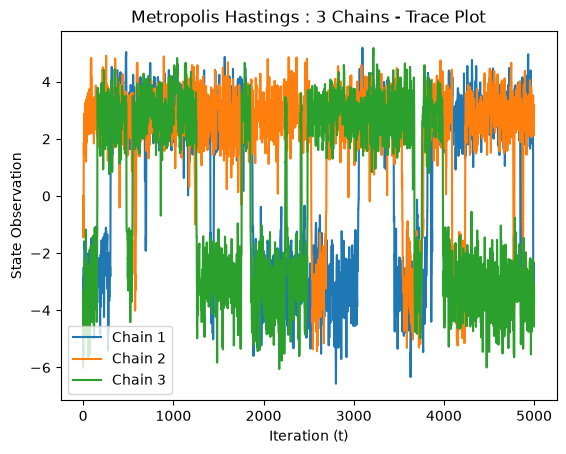

In [28]:
grid = np.linspace(0, 5000, 5000)
plt.plot(
    grid,
    c1,
    label='Chain 1'
)
plt.plot(
    grid,
    c2,
    label='Chain 2'
)
plt.plot(
    grid,
    c3,
    label='Chain 3'
)
plt.legend()
plt.xlabel('Iteration (t)')
plt.ylabel('State Observation')
plt.title('Metropolis Hastings : 3 Chains - Trace Plot')

## Metropolis Hastings General Code